In [4]:
import sys
sys.path.append("./util/")
import widgets as wd
import matplotlib.pyplot as plt
from numpy import arange
import pandas as pd
import os
import numpy as np
stage1_file = '../Fixed_data/64-ch cardiac Day12/'
stage2_file ='../Fixed_data/Device7_Day21_Stage_1/'
stage3_file = '../Fixed_data/Device6_Day46_Stage_3/'
stage4_file = '../Fixed_data/Device2 10042020 Day61/'
stage_file=[stage1_file,stage2_file,stage3_file,stage4_file]


In [5]:
import copy
import pylab
import math
def find_peaks_for_stage_single_plot(cont_data, whiten=False,cutoff=10, filt_bf_avg=1000,
                         rfrac=0.5, n_std_min=5, whole_plot=False, average_plot=True,
                         whole_xlim=[0, 60], average_xlim=[0, 0.2], n_pad_left=1000,
                         n_pad_right=9000,n_pad_left_sub=100, n_pad_right_sub=900,cmap='rainbow',bad_channels=[],
                         n_pad=300,first_spike=False,single_spike=False,save_average_file=False,save_channels=range(0, 64),plot_start=False):
#     cont_data, unit = read_ns4datafile(datafile)
    cont_data_peak_find = copy.deepcopy(cont_data)
    cont_data_peak_find = wd.data_filter(cont_data_peak_find, cutoff=cutoff)
    cont_data_peak_find['data'] = np.diff(cont_data_peak_find['data'], axis=1)
    #cont_data_peak_find['data'] = detrend(cont_data_peak_find['data'],type = 'cons', axis = 0)

    min_dis = rfrac * cont_data['samp_per_s']
    start_peaks = {'time':[],'channel':[]}
    t_spike = arange(n_pad_left + n_pad_right) / cont_data['samp_per_s']
    averaged_spikes = np.zeros([len(cont_data['elec_ids']), n_pad_left + n_pad_right])
    all_spikes = []
    if save_channels:
        NUM_COLORS = len(save_channels)
    else:
        NUM_COLORS = len(cont_data['elec_ids'])
    color = []
    color_idx = 0
    cm = pylab.get_cmap(cmap)
    for i in range(NUM_COLORS):
        color.append(cm(1. * i / NUM_COLORS))  # color will now be an RGBA tuple
    peaks_group = []
#     print(cont_data['elec_ids'])
    for ch in cont_data['elec_ids']:
        channel = ch
        channel_idx = cont_data['elec_ids'].index(ch)
        peak_pos, _ = wd.detect_and_align_peaks_single_channel(cont_data_peak_find, ch, n_std_min,
                                                                1, n_pad, min_dis,first_spike=first_spike)
        peak_neg, _ = wd.detect_and_align_peaks_single_channel(cont_data_peak_find, ch, n_std_min,
                                                                -1, n_pad, min_dis,first_spike=first_spike)
        bad_check = ((len(peak_pos)==0) and (len(peak_neg)==0)) or (ch in bad_channels)
        if bad_check:
            cont_data, _ = wd.bad_channel_remove(cont_data, bad_channel_ids=ch)
            cont_data_peak_find, _ = wd.bad_channel_remove(cont_data_peak_find, bad_channel_ids=ch)
            #print('removed bad channel ' + str(ch))
            bad_spikes = np.zeros([1, n_pad_left + n_pad_right])
            all_spikes.append(bad_spikes)
            peaks_group.append([])
#             continue
        else:
            if filt_bf_avg:
                cont_data = wd.data_filter(cont_data, cutoff=filt_bf_avg)
            peak_pos_averaged_pos, peak_pos_pos = wd.spike_average(cont_data['data'][channel_idx, :], peak_pos, detect_sign=1,
                                                              n_pad_left=n_pad_left, n_pad_right=n_pad_right,
                                                              n_pad_left_sub=n_pad_left_sub,
                                                              n_pad_right_sub=n_pad_right_sub)
            peak_pos_averaged_neg, peak_pos_neg = wd.spike_average(cont_data['data'][channel_idx, :], peak_pos, detect_sign=-1,
                                                              n_pad_left=n_pad_left, n_pad_right=n_pad_right,
                                                              n_pad_left_sub=n_pad_left_sub,
                                                              n_pad_right_sub=n_pad_right_sub)
            peak_neg_averaged_pos, peak_neg_pos = wd.spike_average(cont_data['data'][channel_idx, :], peak_neg, detect_sign=1,
                                                              n_pad_left=n_pad_left, n_pad_right=n_pad_right,
                                                              n_pad_left_sub=n_pad_left_sub,
                                                              n_pad_right_sub=n_pad_right_sub)
            peak_neg_averaged_neg, peak_neg_neg = wd.spike_average(cont_data['data'][channel_idx, :], peak_neg, detect_sign=-1,
                                                              n_pad_left=n_pad_left, n_pad_right=n_pad_right,
                                                              n_pad_left_sub=n_pad_left_sub,
                                                              n_pad_right_sub=n_pad_right_sub)
            cor_pos_pos = wd.spikes_coef(peak_pos_pos, peak_pos_averaged_pos)
            cor_pos_neg = wd.spikes_coef(peak_pos_neg, peak_pos_averaged_neg)
            if len(peak_pos)<=1:
                cor_pos_pos = cor_pos_pos/2
                cor_pos_neg = cor_pos_neg/2
            cor_neg_pos = wd.spikes_coef(peak_neg_pos, peak_neg_averaged_pos)
            cor_neg_neg = wd.spikes_coef(peak_neg_neg, peak_neg_averaged_neg)
            if len(peak_neg)<=1:
                cor_neg_pos = cor_neg_pos/2
                cor_neg_neg = cor_neg_neg/2
            cor_list = [cor_pos_pos,cor_pos_neg,cor_neg_pos,cor_neg_neg]

            cor_list = [0 if math.isnan(x) else x for x in cor_list]
            #print(cor_list)
            cor_max = cor_list.index(max(cor_list))
            if cor_max == 0:
                averaged_spike = peak_pos_averaged_pos
                spikes = peak_pos_pos
                peak = peak_pos
            elif cor_max == 1:
                averaged_spike = peak_pos_averaged_neg
                spikes = peak_pos_neg
                peak = peak_pos
            elif cor_max == 2:
                averaged_spike = peak_neg_averaged_pos
                spikes = peak_neg_pos
                peak = peak_neg
            else:
                averaged_spike = peak_neg_averaged_neg
                spikes = peak_neg_neg
                peak = peak_neg
            if peak:
                peaks_group.append(peak)
            else:
                peaks_group.append([])
            if single_spike and spikes.shape[0]>1:
                averaged_spike = spikes[1, :]
#             print(averaged_spike.shape,type(averaged_spike),type(averaged_spikes))
#             print(ch)
            averaged_spikes[channel_idx, :] = averaged_spike

            all_spikes.append(spikes)
        if whole_plot:
            plt.figure()
            plot_single_channel(cont_data_peak_find, ch, unit)
            plt.scatter(np.array(peak) / cont_data_peak_find['samp_per_s'],
                        cont_data_peak_find['data'][channel_idx, peak],
                        marker="v", c='red', s=40)
            plt.xlim(whole_xlim)
            plt.show()
            plt.figure()
            plot_single_channel(cont_data, ch, unit)
            plt.scatter(np.array(peak) / cont_data['samp_per_s'], cont_data['data'][channel_idx, peak],
                        marker="v", c='red', s=40)
            plt.xlim(whole_xlim)
            plt.show()
        if average_plot:


            plt.figure(figsize=(0.6,0.4))
            if bad_check:
                plt.plot(t_spike, np.zeros(len(t_spike)), linewidth=0.3, color=color[color_idx])
                plt.xlim(average_xlim)
                plt.axis('off')
                plt.savefig(save_average_file+'channel'+str(channel)+'.pdf', transparent=True)
                color_idx = color_idx+1
            else:
                plt.plot(t_spike, spikes.transpose(), color='0.5', alpha=0.2)
                if save_average_file and channel_idx in save_channels:
                    plt.plot(t_spike, averaged_spike, linewidth=0.3,color=color[color_idx])
                    #plt.title(['channel' + str(ch) + ' averaged'])
                    plt.xlim(average_xlim)
                    plt.axis('off')
                    plt.savefig(save_average_file+'channel'+str(channel)+'.pdf', transparent=True)
                    color_idx = color_idx+1
                else:
                    plt.plot(t_spike, averaged_spike, linewidth=0.3)
                    # plt.title(['channel' + str(ch) + ' averaged'])
                    plt.xlim(average_xlim)
                    plt.axis('off')
                    plt.show()
#         if peak[0]==0:
#             continue
#         #if cont_data['data'][channel_idx, peak[0]]<1:
#         loc_start = peak[0]-200
#         if loc_start<0:
#             loc_start=0
#         loc_end = peak[0]+200
#         peak_start = np.argmax(cont_data['data'][channel_idx, loc_start:loc_end])+loc_start
#         start_peaks['time'].append(peak_start)
#         start_peaks['channel'].append(channel_idx)

    start_peaks['channel'] = [x for _, x in sorted(zip(start_peaks['time'], start_peaks['channel']))]
    start_peaks['time'] = sorted(start_peaks['time'])
    if plot_start:
        bad_start1 = np.where((np.diff(start_peaks['time'])) == 0)[0]+1
        bad_start2 = np.where((start_peaks['time']-start_peaks['time'][0])> int(median(start_peaks['time'])))[0]
        good_start = np.setdiff1d(np.arange(len(start_peaks['time'])), np.unique(np.append(bad_start1, bad_start2)))
        start_peaks['time'] = [start_peaks['time'][x] for x in good_start]
        start_peaks['channel'] = [start_peaks['channel'][x] for x in good_start]
        center_time = int(median(start_peaks['time']))
        t_start = center_time - 1000
        if t_start<0:
            t_start=0
        t_end = center_time+1000
        t  = arange(t_end-t_start) / cont_data['samp_per_s']
        all_channel = pd.DataFrame(data=cont_data['data'][start_peaks['channel'],t_start:t_end].transpose())
        all_channel["time(s)"] = t
        all_channel.plot(x="time(s)", ylabel="Output (" + unit + ")", figsize=(10, 5), legend=False,cmap=cmap)
    return averaged_spikes, all_spikes,start_peaks,peaks_group




In [2]:

days = ['./day12plot/day12','./day21plot/day21','./day46plot/day46','./day64plot/day64']

bad_channels_group1 = np.array([ 3, 4, 7, 10, 11, 12, 13, 14, 15, 16])
bad_channels_group2 = 16 + np.array([1, 14, 15, 16])
bad_channels_group4 = 16 * 3 + np.array([ 2, 4, 6, 9])

bad_channels1 = list(np.concatenate((bad_channels_group1,bad_channels_group2, bad_channels_group4), 0))
bad_channels_group2 = 16 + np.array([1, 2, 3, 4, 5, 7, 8, 9, 11, 12, 13, 14, 15, 16])
bad_channels_group3 = 16 * 2 + np.array([1, 3, 5, 7, 11, 13, 14, 15, 16])
bad_channels2 = np.concatenate((bad_channels_group2, bad_channels_group3), 0)

bad_channels_group1 = np.array([1])
bad_channels_group3 = 16 * 2 + np.array([3, 4, 6, 7, 8, 9, 10, 12, 13, 14, 16])
bad_channels_group4 = 16 * 3 + np.array([1, 2, 4, 7, 8])
bad_channels3 = np.concatenate((bad_channels_group1, bad_channels_group3, bad_channels_group4), 0)

bad_channels_group1 = np.array([1,2,3,4,5,15,16])
bad_channels_group2 = 16 + np.array([3, 5, 6, 7, 8, 9,11, 12, 13, 14, 15,16])
bad_channels_group3 = 16 * 2 + np.array([11,13,15,16])
bad_channels_group4 = 16 * 3 + np.array([15])
bad_channels4 = np.concatenate((bad_channels_group1,bad_channels_group2, bad_channels_group3, bad_channels_group4), 0)
bad_channels = [bad_channels1,bad_channels2,bad_channels3,bad_channels4]
stage1_file_folder = ["./Fixed_data/64-ch cardiac Day12","./Fixed_data/Device7_Day21_Stage_1","./Fixed_data/Device6_Day46_Stage_3","./Fixed_data/Device2_10072020 Day64"]
cutoff = [10,10,100,100]
rfrac = [0.7,0.7,0.5,0.5,]
n_std_min = [4,5,10,10]
whole_plot = False
average_plot = True
whole_xlim = [0, 60]
n_pad_left = 5000
n_pad_right = 8000
n_pad_left_sub = [5000,5000,100,100]
n_pad_right_sub = [7000,7000,900,100]
average_xlim = [0, (n_pad_left + n_pad_right) / 10000]
n_pad = [300,300,3000,100]
first_spike = [True,True,False,False]
filt_bf_avg = [1000,1000,None,None]
plot_start = False
single_spike = True


111020_Day12_Device 12_1_002.ns4 opened

111020_Day12_Device 12_1_002.ns4 closed

111020_Day12_Device 12_2_002.ns4 opened

111020_Day12_Device 12_2_002.ns4 closed

111020_Day12_Device 12_3_002.ns4 opened

111020_Day12_Device 12_3_002.ns4 closed

111020_Day12_Device 12_4_002.ns4 opened

111020_Day12_Device 12_4_002.ns4 closed


<Figure size 432x288 with 0 Axes>

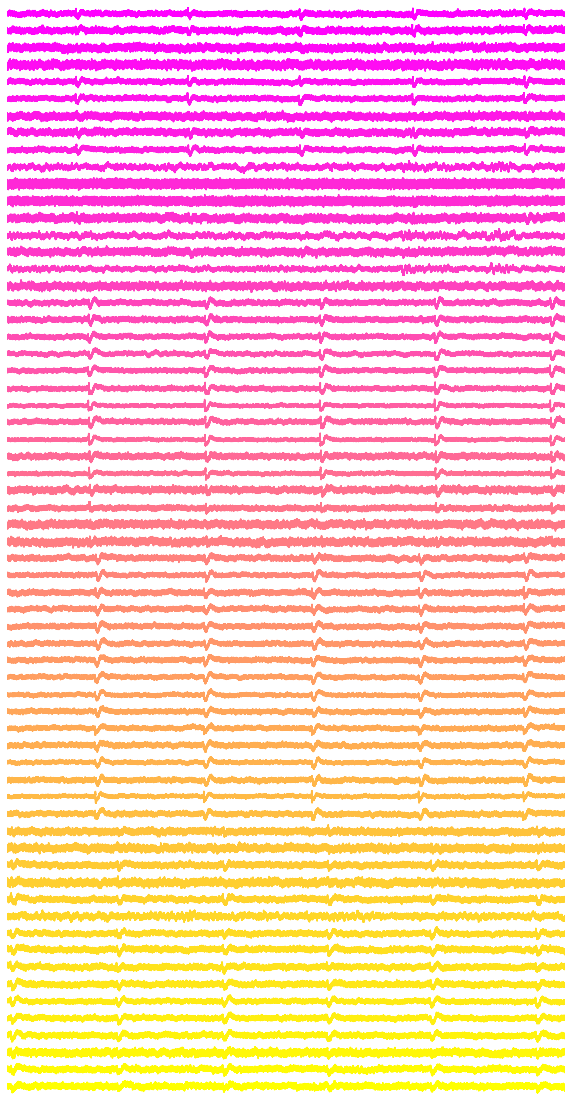

KeyboardInterrupt: 

In [4]:

xlims=[[3.4,33.4],[1.32,31.32],[0,30],[0.94,30.94]]
channels=[np.arange(0,64) for i in range(4)]
cmap=['spring','summer','autumn','winter']

for j in range(len(stage_file)):
#     cont_data_, unit_ = wd.read_ns4datafile(stage_file[j])
    cont_data={'elec_ids':[],'data':[],'samp_per_s':[]}
    dir_single_group = []
    flags = []
    stage_dir_name = os.walk(stage_file[j])
    for path,_,sub_file_list in stage_dir_name:
        for file in sub_file_list:
            if file.endswith("002.ns4"):
                dir_single_group.append(os.path.join(path,file))
                flags.append(file[-9])
        flags_sort_idx = sorted(range(len(flags)), key=lambda k: flags[k])
        flags = []
        for ii,idx in enumerate(flags_sort_idx):
            cont_data_, unit = wd.read_ns4datafile(dir_single_group[idx])
            cont_data['data'].append(cont_data_['data'])
            cont_data['elec_ids'].append([c_id+16*ii for c_id in cont_data_['elec_ids']])
            cont_data['samp_per_s'] = cont_data_['samp_per_s']
    cont_data['data'] = np.concatenate( cont_data['data'], axis=0 )
    cont_data['elec_ids'] = list(np.concatenate( cont_data['elec_ids']))
    plt.figure()
    xlim = xlims[j]
    sub=True
    merge=False
    if xlim:
        t_start = int(xlim[0]*cont_data['samp_per_s'])
        t_end = int(xlim[1]*cont_data['samp_per_s'])
        t  = xlim[0] + arange(t_end-t_start) / cont_data['samp_per_s']
        all_channel = pd.DataFrame(data=cont_data['data'][channels[j],t_start:t_end].transpose())
    else:
        t  = cont_data['start_time_s'] + arange(cont_data['data'].shape[1]) / cont_data['samp_per_s']
        all_channel = pd.DataFrame(data=cont_data['data'][channels[j]].transpose())
    all_channel["time(s)"]=t
    if sub:
        ax = all_channel.plot(x="time(s)",subplots=True,sharex=True,sharey=False,
                         figsize=(10,20), legend=False,cmap=cmap[j])
        
        for i in range(len(ax)):
            ax[i].spines['right'].set_visible(False)
            ax[i].spines['top'].set_visible(False)
            ax[i].spines['left'].set_visible(False)
            ax[i].spines['bottom'].set_visible(False)
            ax[i].axes.get_xaxis().set_visible(False)
            ax[i].axes.get_yaxis().set_visible(False)
        #plt.legend(loc='right')
        if xlim:
            plt.xlim(xlim)
        fig = ax[0].get_figure()
        fig.savefig(days[j]+'whole_plot.pdf')
        
    if merge:
        all_channel.plot(x="time(s)",ylabel = "Output (" + unit + ")",figsize=(10,5), legend=False)
        plt.legend(loc='right')
        if xlim:
            plt.xlim(xlim)
    plt.savefig('stage'+str(j)+'.pdf', transparent=True)
    plt.show()               
    
    averaged_spike = find_peaks_for_stage_single_plot(cont_data, cutoff=cutoff[j],rfrac=rfrac[j], filt_bf_avg=filt_bf_avg[j],
                                         n_std_min=n_std_min[j], whole_plot=whole_plot, 
                                         average_plot=average_plot,whole_xlim=whole_xlim, 
                                         average_xlim=average_xlim, n_pad_left=n_pad_left, bad_channels =bad_channels[j],
                                         n_pad_right=n_pad_right,n_pad_left_sub=n_pad_left_sub[j],
                                         n_pad_right_sub=n_pad_right_sub[j], n_pad=n_pad[j],cmap=cmap[j],
                                         first_spike=first_spike[j],save_average_file=days[j])
    
    

In [8]:
dir_single_group

['../Fixed_data/Mixed Device16/112220_Day24_8_Device 16_4_002.ns4',
 '../Fixed_data/Mixed Device16/112220_Day24_8_Device 16_1_002.ns4',
 '../Fixed_data/Mixed Device16/112220_Day24_8_Device 16_2_002.ns4',
 '../Fixed_data/Mixed Device16/112220_Day24_8_Device 16_3_002.ns4']

In [9]:
flags_sort_idx

[1, 2, 3, 0]


112220_Day24_8_Device 16_1_002.ns4 opened

112220_Day24_8_Device 16_1_002.ns4 closed

112220_Day24_8_Device 16_2_002.ns4 opened

112220_Day24_8_Device 16_2_002.ns4 closed

112220_Day24_8_Device 16_3_002.ns4 opened

112220_Day24_8_Device 16_3_002.ns4 closed

112220_Day24_8_Device 16_4_002.ns4 opened

112220_Day24_8_Device 16_4_002.ns4 closed


<Figure size 432x288 with 0 Axes>

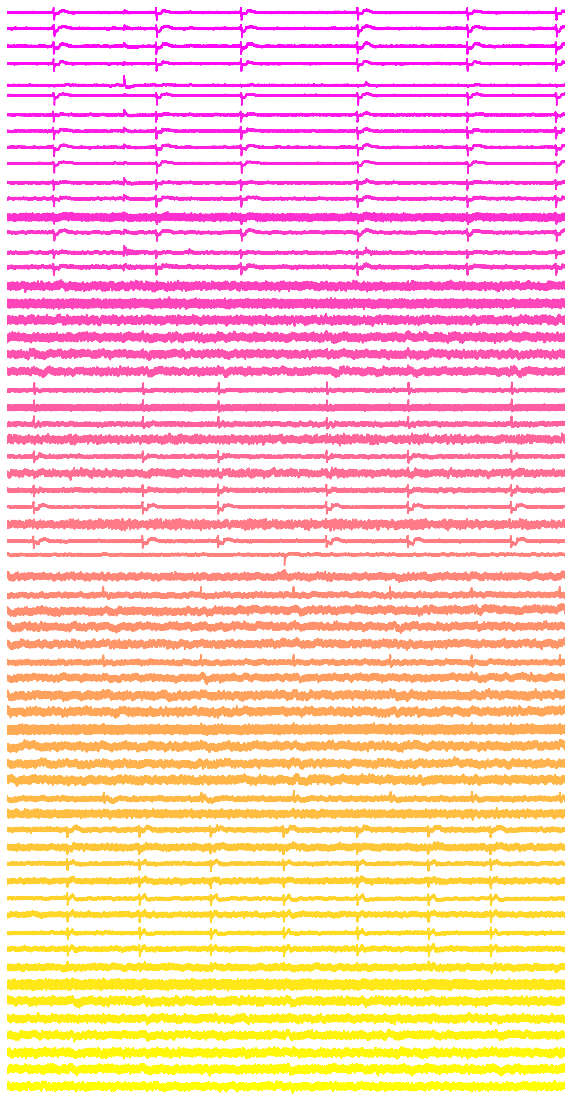

<ipython-input-5-504c921a6502>:125: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(0.6,0.4))
<ipython-input-5-504c921a6502>:125: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(0.6,0.4))
<ipython-input-5-504c921a6502>:125: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=

<ipython-input-5-504c921a6502>:125: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(0.6,0.4))
<ipython-input-5-504c921a6502>:125: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(0.6,0.4))
<ipython-input-5-504c921a6502>:125: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=

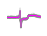

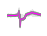

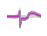

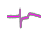

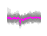

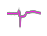

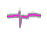

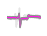

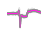

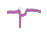

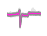

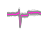

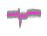

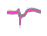

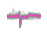

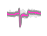

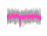

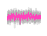

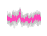

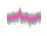

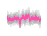

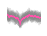

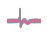

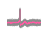

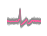

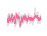

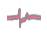

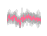

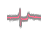

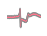

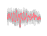

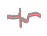

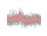

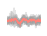

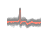

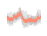

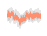

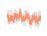

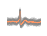

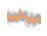

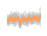

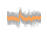

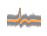

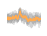

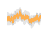

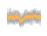

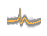

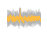

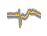

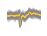

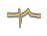

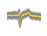

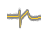

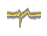

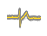

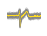

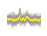

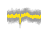

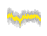

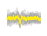

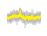

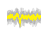

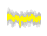

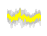

In [10]:
stage_file = ["../Fixed_data/Mixed Device16"]
xlims=[[0,30]]
channels=[np.arange(0,64) for i in range(1)]
cmap=['spring']
days = ['hybrid']
cutoff = [10]
rfrac = [2]
n_std_min = [3]
whole_plot = False
average_plot = True
whole_xlim = [0, 60]
n_pad_left = 5000
n_pad_right = 8000
n_pad_left_sub = [5000]
n_pad_right_sub = [7000]
average_xlim = [0, (n_pad_left + n_pad_right) / 10000]
n_pad = [300]
first_spike = [True]
filt_bf_avg = [1000]
plot_start = False
single_spike = True

#bad_channels_group1 =  np.array([5])
# bad_channels_group2 = 16 + np.array([2,10,12,15])
# bad_channels_group3 = 16 * 2 + np.array([6,13,16])
# bad_channels_group4 = 16 * 3 - 1 + np.array([])
# border_channel = [36, 32, 63, 62]

# bad_channels = [np.concatenate((bad_channels_group2,bad_channels_group3), 0)]
# bad_channels = [np.concatenate((bad_channels_group1,bad_channels_group2,bad_channels_group3), 0)]

bad_channels = [[]]


for j in range(len(stage_file)):
#     cont_data_, unit_ = wd.read_ns4datafile(stage_file[j])
    cont_data={'elec_ids':[],'data':[],'samp_per_s':[]}
    dir_single_group = []
    flags = []
    stage_dir_name = os.walk(stage_file[j])
    for path,_,sub_file_list in stage_dir_name:
        for file in sub_file_list:
            if file.endswith("002.ns4"):
                dir_single_group.append(os.path.join(path,file))
                flags.append(file[-9])
        flags_sort_idx = sorted(range(len(flags)), key=lambda k: flags[k])
        flags = []
        for ii, idx in enumerate(flags_sort_idx):
            cont_data_, unit = wd.read_ns4datafile(dir_single_group[idx])
            cont_data['data'].append(cont_data_['data'])
            cont_data['elec_ids'].append([c_id+16*ii for c_id in cont_data_['elec_ids']])
            cont_data['samp_per_s'] = cont_data_['samp_per_s']
    cont_data['data'] = np.concatenate( cont_data['data'], axis=0 )
    cont_data['elec_ids'] = list(np.concatenate( cont_data['elec_ids']))
    plt.figure()
    xlim = xlims[j]
    sub=True
    merge=False
    if xlim:
        t_start = int(xlim[0]*cont_data['samp_per_s'])
        t_end = int(xlim[1]*cont_data['samp_per_s'])
        t  = xlim[0] + arange(t_end-t_start) / cont_data['samp_per_s']
        all_channel = pd.DataFrame(data=cont_data['data'][channels[j],t_start:t_end].transpose())
    else:
        t  = cont_data['start_time_s'] + arange(cont_data['data'].shape[1]) / cont_data['samp_per_s']
        all_channel = pd.DataFrame(data=cont_data['data'][channels[j]].transpose())
    all_channel["time(s)"]=t
    if sub:
        ax = all_channel.plot(x="time(s)",subplots=True,sharex=True,sharey=False,
                         figsize=(10,20), legend=False,cmap=cmap[j])
        
        for i in range(len(ax)):
            ax[i].spines['right'].set_visible(False)
            ax[i].spines['top'].set_visible(False)
            ax[i].spines['left'].set_visible(False)
            ax[i].spines['bottom'].set_visible(False)
            ax[i].axes.get_xaxis().set_visible(False)
            ax[i].axes.get_yaxis().set_visible(False)
        #plt.legend(loc='right')
        if xlim:
            plt.xlim(xlim)
        fig = ax[0].get_figure()
        fig.savefig(days[j]+'whole_plot.pdf')
        
    if merge:
        all_channel.plot(x="time(s)",ylabel = "Output (" + unit + ")",figsize=(10,5), legend=False)
        plt.legend(loc='right')
        if xlim:
            plt.xlim(xlim)
    plt.savefig('stage'+str(j)+'.pdf', transparent=True)
    plt.show()               
    
    averaged_spike = find_peaks_for_stage_single_plot(cont_data, cutoff=cutoff[j],rfrac=rfrac[j], filt_bf_avg=filt_bf_avg[j],
                                         n_std_min=n_std_min[j], whole_plot=whole_plot, 
                                         average_plot=average_plot,whole_xlim=whole_xlim, 
                                         average_xlim=average_xlim, n_pad_left=n_pad_left, bad_channels =bad_channels[j],
                                         n_pad_right=n_pad_right,n_pad_left_sub=n_pad_left_sub[j],
                                         n_pad_right_sub=n_pad_right_sub[j], n_pad=n_pad[j],cmap=cmap[j],
                                         first_spike=first_spike[j],save_average_file=days[j])



In [82]:
cont_data['data'].shape

(64, 600100)


111020_Day12_Device 12_1_002.ns4 opened

111020_Day12_Device 12_1_002.ns4 closed


<Figure size 432x288 with 0 Axes>

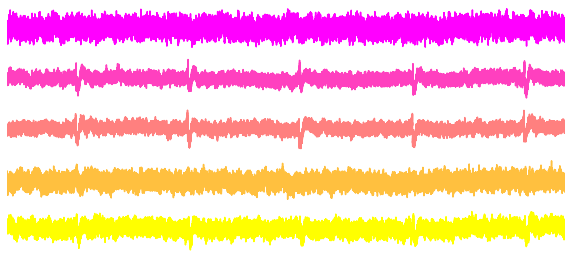


083020_device 7-4_002.ns4 opened

083020_device 7-4_002.ns4 closed


<Figure size 432x288 with 0 Axes>

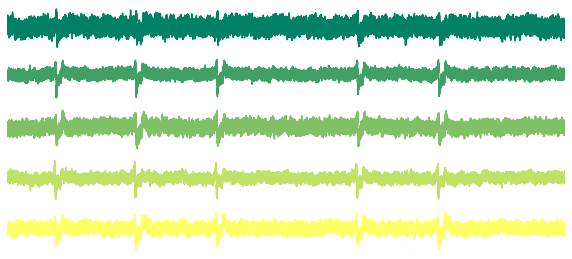


091920_device 6-2_002.ns4 opened

091920_device 6-2_002.ns4 closed


<Figure size 432x288 with 0 Axes>

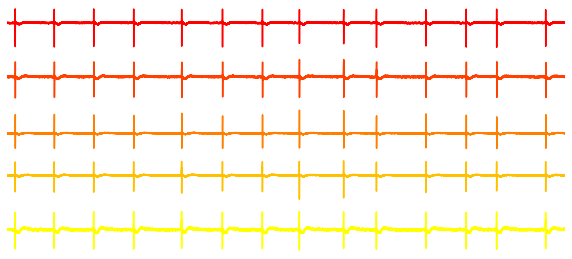


100420_device 2-3_001.ns4 opened

100420_device 2-3_001.ns4 closed


<Figure size 432x288 with 0 Axes>

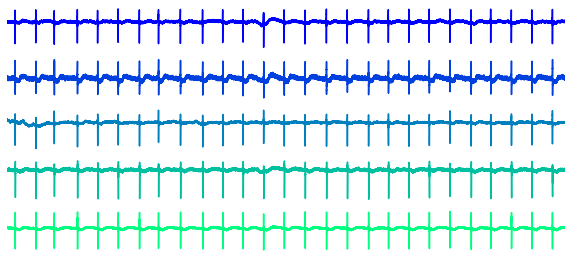

In [4]:
import pylab
xlims=[[3.4,33.4],[1.32,31.32],[0,30],[0.94,30.94]]
cmap=['spring','summer','autumn','winter']
#xlims=[[3.7,4.1],[1.52,1.92],[0.2,0.6],[1.14,1.54]]
channels=[[3,4,5,6,7],[1,2,3,4,5],[1,2,3,4,5],[1,2,5,6,7]]
for j in range(len(stage_file)):
    cont_data_, unit_ = wd.read_ns4datafile(stage_file[j])
    plt.figure()
    xlim = xlims[j]
    sub=True
    merge=False
    if xlim:
        t_start = int(xlim[0]*cont_data['samp_per_s'])
        t_end = int(xlim[1]*cont_data['samp_per_s'])
        t  = xlim[0] + arange(t_end-t_start) / cont_data['samp_per_s']
        all_channel = pd.DataFrame(data=cont_data['data'][channels[j],t_start:t_end].transpose())
    else:
        t  = cont_data['start_time_s'] + arange(cont_data['data'].shape[1]) / cont_data['samp_per_s']
        all_channel = pd.DataFrame(data=cont_data['data'][channels[j]].transpose())
    all_channel["time(s)"]=t
    if sub:
        ax = all_channel.plot(x="time(s)",subplots=True,sharex=True,sharey=False,
                         figsize=(10,5), legend=False,cmap=cmap[j])
    
        for i in range(len(ax)):
            ax[i].spines['right'].set_visible(False)
            ax[i].spines['top'].set_visible(False)
            ax[i].spines['left'].set_visible(False)
            ax[i].spines['bottom'].set_visible(False)
            ax[i].axes.get_xaxis().set_visible(False)
            ax[i].axes.get_yaxis().set_visible(False)
        #plt.legend(loc='right')
        if xlim:
            plt.xlim(xlim)
    if merge:
        all_channel.plot(x="time(s)",ylabel = "Output (" + unit + ")",figsize=(10,5), legend=False)
        plt.legend(loc='right')
        if xlim:
            plt.xlim(xlim)
    plt.savefig('stage'+str(j)+'.pdf', transparent=True)
    plt.show()   
    


083020_device 7-4_002.ns4 opened

083020_device 7-4_002.ns4 closed


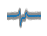

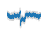

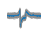

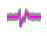

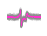

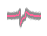

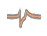

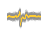

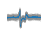

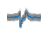

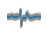

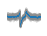

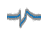

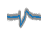

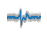

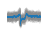

In [3]:
datafile = stage_file[0]
cutoff=10
rfrac=0.7
n_std_min=5
whole_plot=False
average_plot=True
whole_xlim=[0, 60]
n_pad_left=8000
n_pad_right=12000
n_pad_left_sub=5000
n_pad_right_sub=7000
average_xlim=[0, (n_pad_left+n_pad_right)/10000]
n_pad=300
first_spike=True
filt_bf_avg=1000
averaged_spike = wd.find_peaks_for_stage(datafile, cutoff=cutoff,rfrac=rfrac, filt_bf_avg=filt_bf_avg,
                                         n_std_min=n_std_min, whole_plot=whole_plot, 
                                         average_plot=average_plot,whole_xlim=whole_xlim, 
                                         average_xlim=average_xlim, n_pad_left=n_pad_left, 
                                         n_pad_right=n_pad_right,n_pad_left_sub=n_pad_left_sub,
                                         n_pad_right_sub=n_pad_right_sub, n_pad=n_pad,cmap='spring',
                                         first_spike=first_spike,save_average_file='day21',save_channels=channels[0])


090420_device 1-4_001.ns4 opened

090420_device 1-4_001.ns4 closed


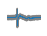

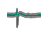

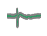

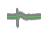

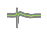

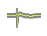

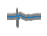

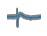

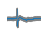

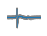

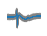

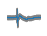

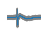

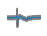

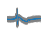

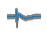

In [4]:
datafile = stage_file[1]
cutoff=100
rfrac=0.5
n_std_min=5
whole_plot=False
average_plot=True
whole_xlim=[0, 60]
n_pad_left=3000
n_pad_right=7000
n_pad_left_sub=100
n_pad_right_sub=900
n_pad=3000
average_xlim=[0, (n_pad_left+n_pad_right)/10000]
first_spike=False
filt_bf_avg=False
averaged_spike = wd.find_peaks_for_stage(datafile, cutoff=cutoff,rfrac=rfrac, filt_bf_avg=filt_bf_avg,
                                         n_std_min=n_std_min, whole_plot=whole_plot, 
                                         average_plot=average_plot,whole_xlim=whole_xlim, 
                                         average_xlim=average_xlim, n_pad_left=n_pad_left, 
                                         n_pad_right=n_pad_right,n_pad_left_sub=n_pad_left_sub,
                                         n_pad_right_sub=n_pad_right_sub, n_pad=n_pad,cmap='summer',
                                         first_spike=first_spike,save_average_file='day31',save_channels=channels[1])


091920_device 6-2_002.ns4 opened

091920_device 6-2_002.ns4 closed


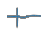

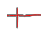

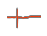

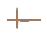

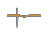

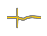

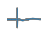

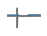

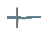

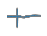

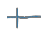

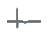

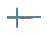

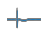

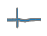

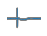

In [5]:
datafile = stage_file[2]
whole_xlim=[0, 60]
cutoff=100
rfrac=0.5
n_std_min=10
whole_plot=False
average_plot=True
n_pad_left=3000
n_pad_right=7000
n_pad_left_sub=100
n_pad_right_sub=900
average_xlim=[0, (n_pad_left+n_pad_right)/10000]
n_pad=3000
first_spike=False
filt_bf_avg=False
averaged_spike = wd.find_peaks_for_stage(datafile, cutoff=cutoff,rfrac=rfrac, filt_bf_avg=filt_bf_avg,
                                         n_std_min=n_std_min, whole_plot=whole_plot, 
                                         average_plot=average_plot,whole_xlim=whole_xlim, 
                                         average_xlim=average_xlim, n_pad_left=n_pad_left, 
                                         n_pad_right=n_pad_right,n_pad_left_sub=n_pad_left_sub,
                                         n_pad_right_sub=n_pad_right_sub, n_pad=n_pad,cmap='autumn',
                                         first_spike=first_spike,save_average_file='day46',save_channels=channels[2])


100420_device 2-3_001.ns4 opened

100420_device 2-3_001.ns4 closed


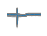

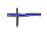

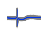

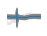

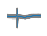

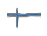

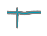

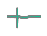

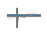

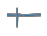

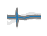

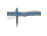

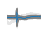

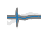

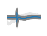

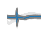

In [6]:
datafile = stage_file[3]
whole_xlim=[0, 60]
cutoff=100
rfrac=0.5
n_std_min=10
whole_plot=False
average_plot=True
n_pad_left=3000
n_pad_right=7000
n_pad_left_sub=100
n_pad_right_sub=100
average_xlim=[0, (n_pad_left+n_pad_right)/10000]
n_pad=100
first_spike=False
filt_bf_avg=False
averaged_spike = wd.find_peaks_for_stage(datafile, cutoff=cutoff,rfrac=rfrac, filt_bf_avg=filt_bf_avg,
                                         n_std_min=n_std_min, whole_plot=whole_plot, 
                                         average_plot=average_plot,whole_xlim=whole_xlim, 
                                         average_xlim=average_xlim, n_pad_left=n_pad_left, 
                                         n_pad_right=n_pad_right,n_pad_left_sub=n_pad_left_sub,
                                         n_pad_right_sub=n_pad_right_sub, n_pad=n_pad,cmap='winter',
                                         first_spike=first_spike,save_average_file='day64',save_channels=channels[3])
            
